In [1]:
import nltk
import string
import math
import pandas as pd

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mrfar\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_pe

True

In [3]:
text = """Text analytics is an important field in data science that focuses on extracting meaningful insights from textual data.
It involves techniques such as tokenization, stop word removal, stemming, and lemmatization.
These methods help in cleaning and transforming unstructured text into structured form, enabling better analysis and decision-making."""

In [4]:
sentences = sent_tokenize(text)
print(sentences)

['Text analytics is an important field in data science that focuses on extracting meaningful insights from textual data.', 'It involves techniques such as tokenization, stop word removal, stemming, and lemmatization.', 'These methods help in cleaning and transforming unstructured text into structured form, enabling better analysis and decision-making.']


In [5]:
words = word_tokenize(text)
print(words)

['Text', 'analytics', 'is', 'an', 'important', 'field', 'in', 'data', 'science', 'that', 'focuses', 'on', 'extracting', 'meaningful', 'insights', 'from', 'textual', 'data', '.', 'It', 'involves', 'techniques', 'such', 'as', 'tokenization', ',', 'stop', 'word', 'removal', ',', 'stemming', ',', 'and', 'lemmatization', '.', 'These', 'methods', 'help', 'in', 'cleaning', 'and', 'transforming', 'unstructured', 'text', 'into', 'structured', 'form', ',', 'enabling', 'better', 'analysis', 'and', 'decision-making', '.']


In [6]:
words = [word for word in words if word not in string.punctuation]
print(words)

['Text', 'analytics', 'is', 'an', 'important', 'field', 'in', 'data', 'science', 'that', 'focuses', 'on', 'extracting', 'meaningful', 'insights', 'from', 'textual', 'data', 'It', 'involves', 'techniques', 'such', 'as', 'tokenization', 'stop', 'word', 'removal', 'stemming', 'and', 'lemmatization', 'These', 'methods', 'help', 'in', 'cleaning', 'and', 'transforming', 'unstructured', 'text', 'into', 'structured', 'form', 'enabling', 'better', 'analysis', 'and', 'decision-making']


In [7]:
stop_words = set(stopwords.words('english'))

filtered_words = [word for word in words if word.lower() not in stop_words]
print(filtered_words)

['Text', 'analytics', 'important', 'field', 'data', 'science', 'focuses', 'extracting', 'meaningful', 'insights', 'textual', 'data', 'involves', 'techniques', 'tokenization', 'stop', 'word', 'removal', 'stemming', 'lemmatization', 'methods', 'help', 'cleaning', 'transforming', 'unstructured', 'text', 'structured', 'form', 'enabling', 'better', 'analysis', 'decision-making']


In [8]:
pos_tags = pos_tag(filtered_words)
print(pos_tags)

[('Text', 'IN'), ('analytics', 'NNS'), ('important', 'JJ'), ('field', 'NN'), ('data', 'NNS'), ('science', 'NN'), ('focuses', 'VBZ'), ('extracting', 'VBG'), ('meaningful', 'JJ'), ('insights', 'NNS'), ('textual', 'JJ'), ('data', 'NNS'), ('involves', 'NNS'), ('techniques', 'NNS'), ('tokenization', 'VBP'), ('stop', 'VB'), ('word', 'NN'), ('removal', 'NN'), ('stemming', 'VBG'), ('lemmatization', 'NN'), ('methods', 'NNS'), ('help', 'VBP'), ('cleaning', 'VBG'), ('transforming', 'NN'), ('unstructured', 'JJ'), ('text', 'NN'), ('structured', 'VBD'), ('form', 'NN'), ('enabling', 'VBG'), ('better', 'JJR'), ('analysis', 'NN'), ('decision-making', 'NN')]


In [9]:
ps = PorterStemmer()
stemmed_words = [ps.stem(word) for word in filtered_words]
print(stemmed_words)

['text', 'analyt', 'import', 'field', 'data', 'scienc', 'focus', 'extract', 'meaning', 'insight', 'textual', 'data', 'involv', 'techniqu', 'token', 'stop', 'word', 'remov', 'stem', 'lemmat', 'method', 'help', 'clean', 'transform', 'unstructur', 'text', 'structur', 'form', 'enabl', 'better', 'analysi', 'decision-mak']


In [10]:
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]
print(lemmatized_words)

['Text', 'analytics', 'important', 'field', 'data', 'science', 'focus', 'extracting', 'meaningful', 'insight', 'textual', 'data', 'involves', 'technique', 'tokenization', 'stop', 'word', 'removal', 'stemming', 'lemmatization', 'method', 'help', 'cleaning', 'transforming', 'unstructured', 'text', 'structured', 'form', 'enabling', 'better', 'analysis', 'decision-making']


In [11]:
documents = [
    "Text analytics is the process of analyzing text data",
    "It helps in extracting useful information",
    "Students are learning NLP techniques"
]

In [12]:
clean_docs = []

for doc in documents:
    words = word_tokenize(doc.lower())
    words = [word for word in words if word not in stop_words and word not in string.punctuation]
    clean_docs.append(" ".join(words))

print(clean_docs)

['text analytics process analyzing text data', 'helps extracting useful information', 'students learning nlp techniques']


In [13]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_docs)

In [14]:
df = pd.DataFrame(X.toarray(),
                  columns=vectorizer.get_feature_names_out(),
                  index=["Document 1", "Document 2", "Document 3"])

print(df)

            analytics  analyzing      data  extracting  helps  information  \
Document 1   0.353553   0.353553  0.353553         0.0    0.0          0.0   
Document 2   0.000000   0.000000  0.000000         0.5    0.5          0.5   
Document 3   0.000000   0.000000  0.000000         0.0    0.0          0.0   

            learning  nlp   process  students  techniques      text  useful  
Document 1       0.0  0.0  0.353553       0.0         0.0  0.707107     0.0  
Document 2       0.0  0.0  0.000000       0.0         0.0  0.000000     0.5  
Document 3       0.5  0.5  0.000000       0.5         0.5  0.000000     0.0  


In [15]:
def computeTF(word_dict, words):
    tf_dict = {}
    total_words = len(words)
    for word, count in word_dict.items():
        tf_dict[word] = count / total_words
    return tf_dict

def computeIDF(documents):
    N = len(documents)
    idf_dict = {}
    all_words = set(word for doc in documents for word in doc)
    for word in all_words:
        count = sum(1 for doc in documents if word in doc)
        idf_dict[word] = math.log(N / count)
    return idf_dict

def computeTFIDF(tf, idf):
    tfidf = {}
    for word in tf:
        tfidf[word] = tf[word] * idf[word]
    return tfidf

In [18]:
doc1_words = [word for word in word_tokenize(documents[0].lower()) 
              if word not in stop_words and word not in string.punctuation]

doc2_words = [word for word in word_tokenize(documents[1].lower()) 
              if word not in stop_words and word not in string.punctuation]

all_words = set(doc1_words + doc2_words)

docs = [doc1_words, doc2_words]
idf = computeIDF(docs)

# Doc1
word_dict1 = dict.fromkeys(all_words, 0)
for word in doc1_words:
    word_dict1[word] += 1

tf1 = computeTF(word_dict1, doc1_words)
tfidf1 = computeTFIDF(tf1, idf)

# Doc2
word_dict2 = dict.fromkeys(all_words, 0)
for word in doc2_words:
    word_dict2[word] += 1

tf2 = computeTF(word_dict2, doc2_words)
tfidf2 = computeTFIDF(tf2, idf)

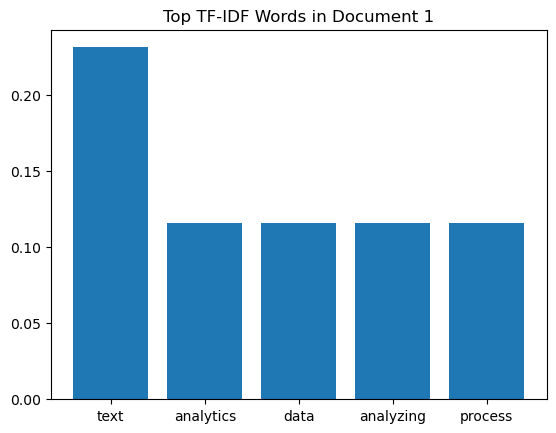

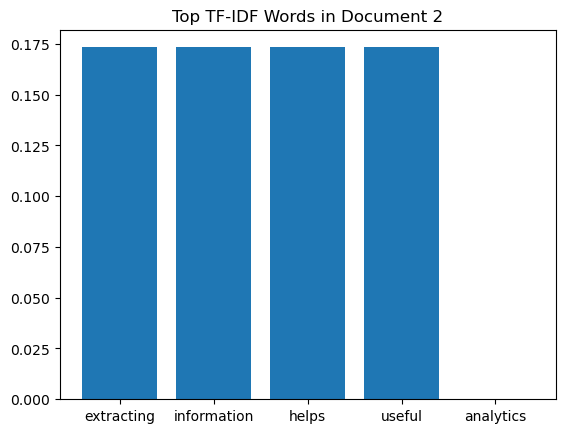

In [19]:
import matplotlib.pyplot as plt

top_words_doc1 = dict(sorted(tfidf1.items(), key=lambda x: x[1], reverse=True)[:5])
top_words_doc2 = dict(sorted(tfidf2.items(), key=lambda x: x[1], reverse=True)[:5])

plt.figure()
plt.bar(top_words_doc1.keys(), top_words_doc1.values())
plt.title("Top TF-IDF Words in Document 1")
plt.show()

plt.figure()
plt.bar(top_words_doc2.keys(), top_words_doc2.values())
plt.title("Top TF-IDF Words in Document 2")
plt.show()